In [ ]:
# ==============================
# 1. Mount Google Drive
# ==============================
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
# The zip file that was extracted is now in /content
zip_path = '/content/drive/MyDrive/cats_vs_dogs_small.zip'
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Colab Notebooks', 'Google AI Studio', 'cats_vs_dogs_small.zip']


In [ ]:
pip install tensorflow

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications

In [ ]:
base_dir = "/content/cats_vs_dogs_small"

full_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "train"),
    image_size=(180, 180),
    batch_size=32,
    shuffle=True,
    seed=123
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "validation"),
    image_size=(180, 180),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, "test"),
    image_size=(180, 180),
    batch_size=32
)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
# Display sample images
def show_images(dataset):
    plt.figure(figsize=(10, 10))
    for images, model_labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title("Cat" if model_labels[i] == 0 else "Dog")
            plt.axis("off")
    plt.show()

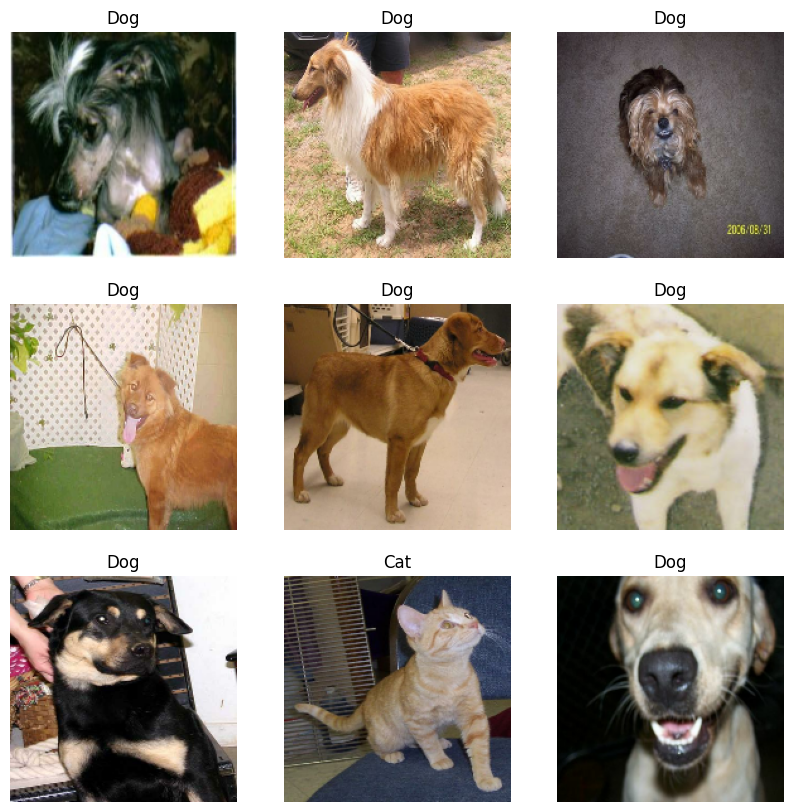

In [ ]:
# Call the function to display images
show_images(full_train_ds)

CNN from Scratch - 1000 samples

In [ ]:
train_ds = full_train_ds.take(32)  # ~1024 samples

model = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(train_ds, epochs=20, validation_data=validation_ds)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy CNN 1000 samples: {test_acc:.3f}")


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5127 - loss: 0.7112 - val_accuracy: 0.5000 - val_loss: 0.7044
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.4814 - loss: 0.6957 - val_accuracy: 0.5220 - val_loss: 0.6915
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5176 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5088 - loss: 0.6938 - val_accuracy: 0.5610 - val_loss: 0.6871
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5557 - loss: 0.6901 - val_accuracy: 0.5610 - val_loss: 0.6819
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5684 - loss: 0.6882 - val_accuracy: 0.6180 - val_loss: 0.6654
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5889 - loss: 0.6818 - val_accuracy: 0.5530 - val_loss: 0.6815
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6211 - loss: 0.6472 - val_accuracy: 0.6490 - 

**Plot CNN Accuracy (1000 samples)**

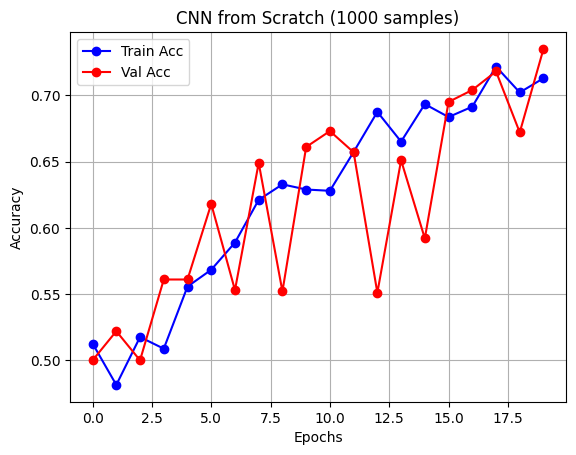

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label="Train Acc")
plt.plot(history.history['val_accuracy'], 'ro-', label="Val Acc")
plt.title("CNN from Scratch (1000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**CNN - 1500 Samples**

In [ ]:
train_ds = full_train_ds.take(47)  # ~1500 samples

model = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, epochs=20, validation_data=validation_ds)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy CNN 1500 samples: {test_acc:.3f}")


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.5020 - loss: 0.7209 - val_accuracy: 0.4990 - val_loss: 0.6911
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5286 - loss: 0.6949 - val_accuracy: 0.5080 - val_loss: 0.6893
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5658 - loss: 0.6911 - val_accuracy: 0.6300 - val_loss: 0.6774
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5698 - loss: 0.6774 - val_accuracy: 0.5390 - val_loss: 0.7132
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6124 - loss: 0.6681 - val_accuracy: 0.6690 - val_loss: 0.6393
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6569 - loss: 0.6357 - val_accuracy: 0.6770 - val_loss: 0.6005
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6582 - loss: 0.6374 - val_accuracy: 0.6420 - val_loss: 0.6182
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6476 - loss: 0.6239 - val_accuracy: 0.6850 - 

**Plot CNN Accuracy (1500 samples)**

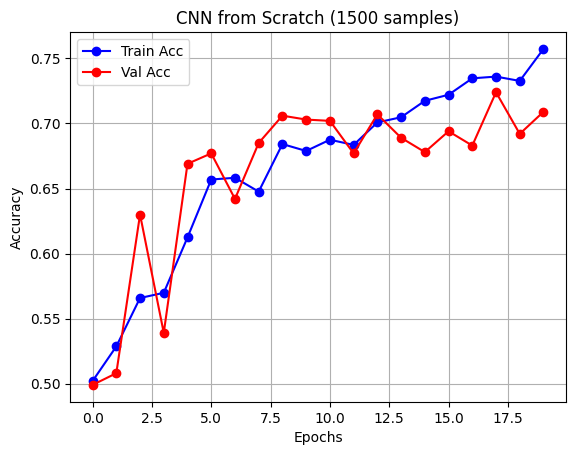

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label="Train Acc")
plt.plot(history.history['val_accuracy'], 'ro-', label="Val Acc")
plt.title("CNN from Scratch (1500 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**CNN - 2000 Samples**

In [ ]:
train_ds = full_train_ds.take(63)  # ~2000 samples

model = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, epochs=20, validation_data=validation_ds)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy CNN 2000 samples: {test_acc:.3f}")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5055 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.8701
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5625 - loss: 0.7044 - val_accuracy: 0.5440 - val_loss: 0.6674
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6220 - loss: 0.6574 - val_accuracy: 0.5250 - val_loss: 0.8634
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6305 - loss: 0.6353 - val_accuracy: 0.5330 - val_loss: 0.7849
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6660 - loss: 0.6168 - val_accuracy: 0.6400 - val_loss: 0.6082
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6685 - loss: 0.6132 - val_accuracy: 0.6790 - val_loss: 0.5903
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6825 - loss: 0.5958 - val_accuracy: 0.6520 - val_loss: 0.6184
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6975 - loss: 0.5825 - val_accuracy: 0.5650 - v

**Plot CNN Accuracy (2000 samples)**

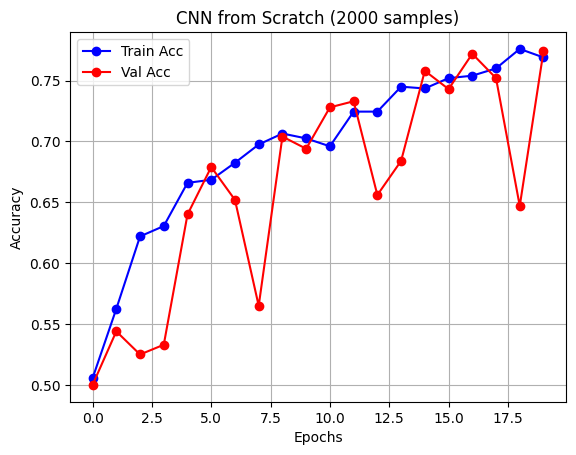

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label="Train Acc")
plt.plot(history.history['val_accuracy'], 'ro-', label="Val Acc")
plt.title("CNN from Scratch (2000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**VGG16 – 1000 Samples**

In [ ]:
train_ds = full_train_ds.take(32)  # ~1000 samples

# Data Augmentation
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

# Load base model
conv_base = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)
conv_base.trainable = False  # Freeze pretrained layers

# Build model
inputs = keras.Input(shape=(180, 180, 3))
x = data_aug(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

# Compile model with learning rate tuning
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

# Train
history = model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=callbacks)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"VGG16 (1000 samples) Test Accuracy: {test_acc:.3f}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy: 0.6162 - loss: 5.5582 - val_accuracy: 0.8130 - val_loss: 1.4795
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.7129 - loss: 3.5290 - val_accuracy: 0.9020 - val_loss: 0.7878
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.7822 - loss: 2.2602 - val_accuracy: 0.9310 - val_loss: 0.5862
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.8154 - loss: 2.0084 - val_accuracy: 0.9370 - val_loss: 0.4906
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.8516 - loss: 1.6058 - val_accuracy: 0.9460 - val_loss: 0.4083
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.8760 - loss: 1.2556 - val_accuracy: 0.9530 - val_loss: 0.3676
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.8789 - loss: 1.2210 - val_accuracy: 0.9550 - val_loss: 0.3433
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step 

**Plot for Accuracy for 1000 Samples**

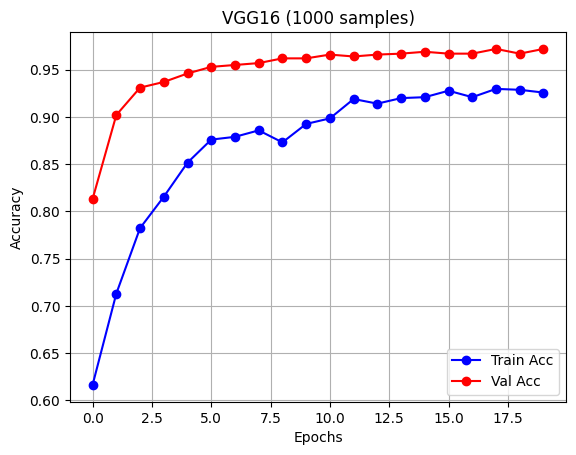

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'ro-', label='Val Acc')
plt.title("VGG16 (1000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**VGG16 – 1500 Samples**


In [ ]:
train_ds = full_train_ds.take(47)  # ~1500 samples

conv_base.trainable = False  # Re-freeze if needed

inputs = keras.Input(shape=(180, 180, 3))
x = data_aug(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.RMSprop(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=callbacks)

test_loss, test_acc = model.evaluate(test_ds)
print(f"VGG16 (1500 samples) Test Accuracy: {test_acc:.3f}")

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.6150 - loss: 5.1536 - val_accuracy: 0.8300 - val_loss: 1.4519
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.7513 - loss: 2.8484 - val_accuracy: 0.9010 - val_loss: 0.7393
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.8198 - loss: 2.0341 - val_accuracy: 0.9320 - val_loss: 0.5002
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8610 - loss: 1.3463 - val_accuracy: 0.9420 - val_loss: 0.4092
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.8810 - loss: 1.2304 - val_accuracy: 0.9440 - val_loss: 0.3708
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.8936 - loss: 1.0201 - val_accuracy: 0.9520 - val_loss: 0.3389
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8936 - loss: 1.0034 - val_accuracy: 0.9560 - val_loss: 0.3058
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.9016 - loss: 0.9198 - val_accuracy:

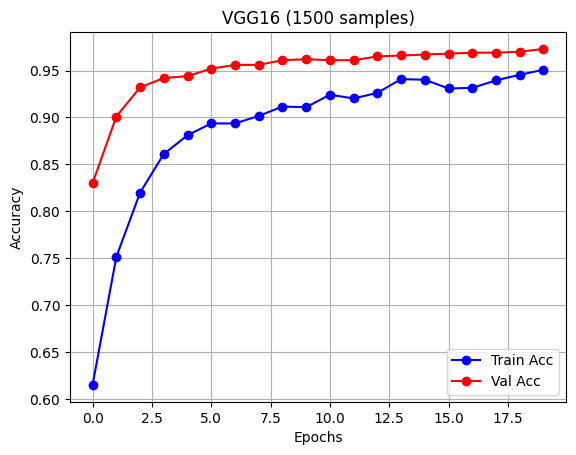

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'ro-', label='Val Acc')
plt.title("VGG16 (1500 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**VGG16 – 2000 Samples**

In [ ]:
train_ds = full_train_ds.take(63)  # ~2000 samples

conv_base.trainable = False

inputs = keras.Input(shape=(180, 180, 3))
x = data_aug(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.RMSprop(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=callbacks)

test_loss, test_acc = model.evaluate(test_ds)
print(f"VGG16 (2000 samples) Test Accuracy: {test_acc:.3f}")


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.6290 - loss: 5.6089 - val_accuracy: 0.8690 - val_loss: 1.0881
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.7970 - loss: 2.4195 - val_accuracy: 0.9190 - val_loss: 0.6526
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.8535 - loss: 1.5794 - val_accuracy: 0.9440 - val_loss: 0.5030
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.8730 - loss: 1.3772 - val_accuracy: 0.9510 - val_loss: 0.4213
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.8890 - loss: 1.1294 - val_accuracy: 0.9610 - val_loss: 0.3688
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.8965 - loss: 1.0240 - val_accuracy: 0.9630 - val_loss: 0.3462
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9155 - loss: 0.8334 - val_accuracy: 0.9670 - val_loss: 0.3285
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.9220 - loss: 0.7051 - val_accuracy: 0

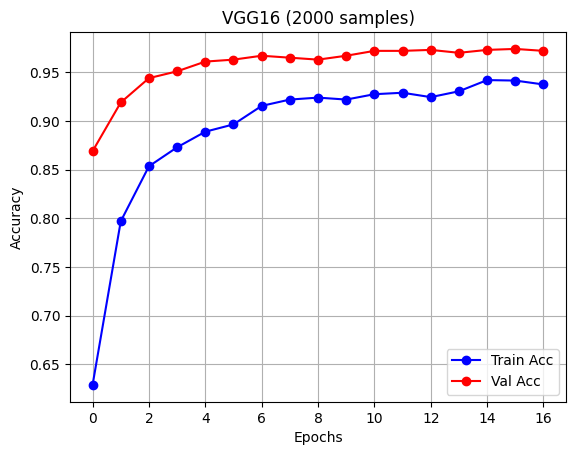

In [ ]:
plt.plot(history.history['accuracy'], 'bo-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'ro-', label='Val Acc')
plt.title("VGG16 (2000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
